# Construcción de Variables: Distancia a Centros de Represión (1970 - 1988)

Este notebook documenta y ejecuta el proceso de construcción de la base de datos `mecanismos_recintos_de_detencion.dta`. 

In [14]:
import requests
from bs4 import BeautifulSoup
import warnings
import pandas as pd
import unicodedata
import re
import numpy as np
from math import radians, cos, sin, asin, sqrt

warnings.filterwarnings('ignore') # Ocultar alertas SSL de la página del gobierno

# Rutas Base
PATH_MA = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/base_unificada_ma_elecciones_comunas1970.csv'
PATH_OUT = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/mecanismos_recintos_de_detencion.dta'

# 1. Extracción desde la Web Oficial del Ministerio de Justicia
url = 'https://pdh.minjusticia.gob.cl/recintos-de-detencion/'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers, verify=False)
soup = BeautifulSoup(response.text, 'html.parser')

texto_crudo = soup.get_text('\n')
lineas = [x.strip() for x in texto_crudo.split('\n') if x.strip()]

# 2. Diccionarios de Normalización y Homologación Geográfica a 1970
SPELLING = {
    'AYSEN':'AISEN','COYHAIQUE':'COIHAIQUE','PAIHUANO':'PAIGUANO',
    'TREHUACO':'TREGUACO','MARCHIGUE':'MARCHIHUE'
}

def normalizar_txt(txt):
    if pd.isna(txt) or txt is None: return ''
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z ]', '', txt).strip()
    return SPELLING.get(txt, txt)

MODERNO_A_HISTORICO = {
    'ANTOFAGASTA': 'AGUAS BLANCAS', 'PORVENIR': 'BAHIA INUTIL', 'TORTEL': 'BAKER', 'LO PRADO': 'BARRANCAS', 
    'PUTRE': 'BELEN', 'TALTAL': 'CATALINA', 'TORRES DEL PAINE': 'CERRO CASTILLO', 'CAMARONES': 'CODPA', 
    'CHILE CHICO': 'GENERAL CARRERA', 'HIJUELAS': 'LA CALERA', 'FUTRONO': 'LAGO RANGO', 'POZO ALMONTE': 'LAGUNAS', 
    'LLAILLAY': 'LLAYLLAY', 'PUNTA ARENAS': 'MAGALLANES', 'CANELA': 'MINCHA', 'LAGUNA BLANCA': 'MORRO CHICO', 
    'CABO DE HORNOS': 'NAVARINO', 'COLCHANE': 'NEGREIROS', 'HUARA': 'PISAGUA', 'QUILLECO': 'QUILECO', 
    'LITUECHE': 'ROSARIO', 'RIO HURTADO': 'SAMO ALTO', 'MARIA ELENA': 'TOCO', 'MACUL': 'NUNOA', 
    'PEÑALOLEN': 'NUNOA', 'SAN JOAQUIN': 'SAN MIGUEL', 'PEDRO AGUIRRE CERDA': 'SAN MIGUEL', 'LO ESPEJO': 'SAN MIGUEL', 
    'CERRILLOS': 'MAIPU', 'ESTACION CENTRAL': 'SANTIAGO', 'QUINTA NORMAL': 'SANTIAGO', 'RECOLETA': 'CONCHALI', 
    'INDEPENDENCIA': 'CONCHALI', 'HUECHURABA': 'CONCHALI', 'PUDAHUEL': 'BARRANCAS', 'CERRO NAVIA': 'BARRANCAS', 
    'LA FLORIDA': 'FLORIDA', 'EL BOSQUE': 'SAN BERNARDO', 'LA PINTANA': 'SAN BERNARDO', 'SAN RAMON': 'LA GRANJA', 
    'VITACURA': 'LAS CONDES', 'LO BARNECHEA': 'LAS CONDES', 'LA CISTERNA': 'LA CISTERNA'
}

df_ma = pd.read_csv(PATH_MA)
comunas_1970_norm = set(df_ma['comuna'].apply(normalizar_txt))

# 3. Parsear Recintos, Asignar Tipo y Comuna
recintos = []
current_region = ""
current_provincia = ""
en_menu = True

for linea in lineas:
    if 'XV Región' in linea:
        en_menu = False
        
    if en_menu: continue
    
    # Detener el parseo al llegar al footer de la página
    if 'Ministerio de Justicia' in linea or 'Agustinas' in linea or 'Consulta' in linea:
        break
        
    if 'Región' in linea and len(linea) < 60:
        current_region = linea
    elif 'Provincia:' in linea:
        current_provincia = linea.replace('Provincia:', '').strip()
    else:
        # Detectamos un recinto
        if current_provincia and current_region and len(linea) > 5 and 'http' not in linea:
            nombre = linea
            
            # Clasificación del recinto (Intensidad Represiva)
            n_upper = normalizar_txt(nombre)
            tipo = "Otro"
            if "DINA" in n_upper or "CNI" in n_upper or "CASA DE LA RISA" in n_upper or "VILLA GRIMALDI" in n_upper or "LONDRES 38" in n_upper or "SIM" in n_upper:
                tipo = "DINA/CNI"
            elif "REGIMIENTO" in n_upper or "BATALLON" in n_upper or "FUERTE" in n_upper or "BASE A" in n_upper or "BASE NAVAL" in n_upper or "ACADEMIA DE GUERRA" in n_upper or "DESTACAMENTO" in n_upper or "ESCUELA DE ARTILLERIA" in n_upper or "DIVISION" in n_upper or "ARSENALES" in n_upper or "ESCUELA DE CABALLERIA" in n_upper or "ESCUELA NAVAL" in n_upper or "ESCUELA DE AVIACION" in n_upper:
                tipo = "Regimiento"
            elif "COMISARIA" in n_upper or "RETEN" in n_upper or "TENENCIA" in n_upper or "PREFECTURA" in n_upper or "SUBCOMISARIA" in n_upper:
                tipo = "Comisaria"
            elif "CAMPAMENTO" in n_upper or "CAMPO" in n_upper or "ESTADIO" in n_upper or "COLONIA DIGNIDAD" in n_upper or "ISLA DAWSON" in n_upper or "CHACABUCO" in n_upper or "PISAGUA" in n_upper:
                tipo = "Campamento"
            elif "CARCEL" in n_upper or "BUEN PASTOR" in n_upper or "PENITENCIARIA" in n_upper:
                tipo = "Carcel"
                
            # Asignación Heurística a Comuna 1970
            comuna = ""
            
            # Hardcode para la corrección manual de Colonia Dignidad
            if "COLONIA DIGNIDAD" in n_upper:
                comuna = "PARRAL"
                
            if not comuna:
                parts = re.split(r'[,.]', nombre)
                if len(parts) > 1:
                    comuna_cand = normalizar_txt(parts[-1])
                    if comuna_cand in comunas_1970_norm:
                        comuna = comuna_cand
                    else:
                        cand_hist = MODERNO_A_HISTORICO.get(comuna_cand, comuna_cand)
                        if cand_hist in comunas_1970_norm:
                            comuna = cand_hist
                            
            if not comuna:
                for c in comunas_1970_norm:
                    if c in n_upper:
                        comuna = c
                        break
                        
            if not comuna:
                prov = normalizar_txt(current_provincia)
                if prov in comunas_1970_norm:
                    comuna = prov
                else:
                    prov_hist = MODERNO_A_HISTORICO.get(prov, prov)
                    if prov_hist in comunas_1970_norm:
                        comuna = prov_hist
                        
            recintos.append({
                'nombre': nombre,
                'tipo': tipo,
                'region': current_region,
                'provincia': current_provincia,
                'comuna_asig': comuna
            })

df_rec = pd.DataFrame(recintos)
print(f"Total recintos extraídos en vivo desde la web: {len(df_rec)}")


Total recintos extraídos en vivo desde la web: 631


## 1. Carga y Agregación de Recintos por Comuna
Primero, cargamos la base de recintos extraídos desde el sitio web del Programa de Derechos Humanos. 
Cada recinto ya fue clasificado por tipo (DINA/CNI, Regimiento, Comisaría, Campamento, Cárcel, Otro) y georreferenciado a los límites comunales de 1970. Agrupamos esta información para contar el número de recintos por comuna.

In [15]:
# Como df_rec ya fue creado en el bloque de web scraping anterior,
# simplemente continuamos trabajando sobre él directamente.

# 1. Filtrar recintos válidos con comuna asignada
df_rec = df_rec[df_rec['comuna_asig'].notna() & (df_rec['comuna_asig'] != '')]

# 2. Crear dummies por tipo de recinto
dummies = pd.get_dummies(df_rec['tipo'], prefix='n')
df_rec = pd.concat([df_rec, dummies], axis=1)

# 3. Renombrar las columnas para que calcen con el formato esperado
cols_rename = {
    'n_DINA/CNI': 'n_dina_cni',
    'n_Regimiento': 'n_regimientos',
    'n_Comisaria': 'n_comisarias',
    'n_Campamento': 'n_campos',
    'n_Carcel': 'n_carceles',
    'n_Otro': 'n_otros'
}
df_rec = df_rec.rename(columns=cols_rename)

# 4. Agregar a nivel de comuna histórica (1970)
agg_dict = {'nombre': 'count'}
for col in cols_rename.values():
    if col in df_rec.columns:
        agg_dict[col] = 'sum'

df_agg = df_rec.groupby('comuna_asig').agg(agg_dict).reset_index()
df_agg = df_agg.rename(columns={'comuna_asig': 'comuna', 'nombre': 'n_recintos_total'})

print(f"Comunas históricas con al menos un recinto asignado: {len(df_agg)}")
df_agg.head()


Comunas históricas con al menos un recinto asignado: 204


,comuna,n_recintos_total,n_dina_cni,n_regimientos,n_comisarias,n_campos,n_carceles,n_otros
0,AGUAS BLANCAS,20,2,3,5,3,2,5
1,ALGARROBO,1,0,0,1,0,0,0
2,ALHUE,1,0,0,1,0,0,0
3,ANCUD,3,0,0,1,0,1,1
4,ANDACOLLO,1,0,0,1,0,0,0


## 2. Integración Espacial y Definición de Zonas Principales
Hacemos un merge con la base unificada de Market Access (que contiene la `latitud`, `longitud` y `region_actual` de cada comuna de 1970). Solo se extraen estas variables para calcular las distancias, el merge con la base principal se realiza despues en stata

**Definición de Zona Principal de Detención:**
Consideramos que una comuna es un centro neurálgico de represión o control militar si cuenta con al menos uno de los siguientes recintos institucionales pesados:
1. Centros DINA/CNI (Inteligencia)
2. Campamentos de Prisioneros (Concentración)
3. Regimientos o Bases Militares (Fuerza Armada)


In [16]:
# Cargar base principal para obtener coordenadas
df_ma = pd.read_csv(PATH_MA)[['comuna', 'latitud', 'longitud', 'region_actual']]

# Merge (Left join para mantener las 279 comunas de 1970)
df_final = df_ma.merge(df_agg, on='comuna', how='left')

# Rellenar con 0 aquellas comunas sin recintos registrados
rep_cols = list(cols_rename.values()) + ['n_recintos_total']
for c in rep_cols:
    if c in df_final.columns:
        df_final[c] = df_final[c].fillna(0)

# Definir Dummy de Zona Principal
df_final['es_zona_principal'] = (
    (df_final['n_dina_cni'] > 0) | 
    (df_final['n_campos'] > 0) | 
    (df_final['n_regimientos'] > 0)
).astype(int)

print(f"Total Zonas Principales en el país: {df_final['es_zona_principal'].sum()}")


Total Zonas Principales en el país: 42


## 3. Cálculo de Distancias 
Para testear la hipótesis de proximidad/aislamiento al aparato coercitivo, calculamos la distancia geográfica en kilómetros desde el centroide de cada comuna hacia la **Zona Principal de Detención más cercana dentro de su misma región**.

Si una región no posee zonas principales (muy raro), se busca la más cercana a nivel nacional.


In [17]:
def euclidiana_km(lon1, lat1, lon2, lat2):
    """Calcula distancia euclidiana en km ajustando por la latitud media."""
    # Convertimos a radianes para calcular el coseno de la latitud media
    lat_mid = radians((lat1 + lat2) / 2.0)
    
    # 1 grado de latitud equivale a ~111.32 km
    # 1 grado de longitud equivale a ~111.32 km * cos(latitud)
    dx = (lon2 - lon1) * 111.32 * cos(lat_mid)
    dy = (lat2 - lat1) * 111.32
    
    # Distancia Euclidiana (Teorema de Pitágoras)
    return np.sqrt(dx**2 + dy**2)

zonas_principales = df_final[df_final['es_zona_principal'] == 1]

distancias = []
for idx, row in df_final.iterrows():
    if pd.isna(row['latitud']) or pd.isna(row['longitud']):
        distancias.append(np.nan)
        continue
        
    if row['es_zona_principal'] == 1:
        # Si la comuna YA ES una zona principal, su distancia es 0
        distancias.append(0.0)
    else:
        # Filtrar las zonas principales que están en la MISMA región
        zonas_region = zonas_principales[zonas_principales['region_actual'] == row['region_actual']]
        
        # Opcional: Si la región no tiene zonas principales registradas, buscar la más cercana a nivel nacional
        zonas_a_buscar = zonas_region if not zonas_region.empty else zonas_principales
        
        min_dist = float('inf')
        for _, z in zonas_a_buscar.iterrows():
            d = euclidiana_km(row['longitud'], row['latitud'], z['longitud'], z['latitud'])
            if d < min_dist:
                min_dist = d
        distancias.append(min_dist)

df_final['distancia_zona_principal_km'] = distancias

# Variables estandarizadas y dummies para las regresiones
df_final['distancia_100km'] = df_final['distancia_zona_principal_km'] / 100.0
df_final['cerca_zona_represion_50km'] = (df_final['distancia_zona_principal_km'] <= 50).astype(int)

# Las comunas sin datos de coordenadas quedan con valores nulos
df_final.loc[df_final['distancia_zona_principal_km'].isna(), 'cerca_zona_represion_50km'] = np.nan


## 3.2 Cálculo de Distancia en términos de tiempo

In [18]:
# ==============================================================================
# NUEVO: Cálculo de Tiempo de Viaje usando Matriz OD 1970
# ==============================================================================
BASE_DISTANCIA = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/'
matriz_1970 = BASE_DISTANCIA + 'matriz_OD_1970.csv'

# Diccionario inverso para buscar el nombre moderno si la comuna histórica no está en la OD
MODERNO_A_HISTORICO = {
    'ANTOFAGASTA': 'AGUAS BLANCAS', 'PORVENIR': 'BAHIA INUTIL', 'TORTEL': 'BAKER', 'LO PRADO': 'BARRANCAS', 
    'PUTRE': 'BELEN', 'TALTAL': 'CATALINA', 'TORRES DEL PAINE': 'CERRO CASTILLO', 'CAMARONES': 'CODPA', 
    'CHILE CHICO': 'GENERAL CARRERA', 'HIJUELAS': 'LA CALERA', 'FUTRONO': 'LAGO RANGO', 'POZO ALMONTE': 'LAGUNAS', 
    'LLAILLAY': 'LLAYLLAY', 'PUNTA ARENAS': 'MAGALLANES', 'CANELA': 'MINCHA', 'LAGUNA BLANCA': 'MORRO CHICO', 
    'CABO DE HORNOS': 'NAVARINO', 'COLCHANE': 'NEGREIROS', 'HUARA': 'PISAGUA', 'QUILLECO': 'QUILECO', 
    'LITUECHE': 'ROSARIO', 'RIO HURTADO': 'SAMO ALTO', 'MARIA ELENA': 'TOCO', 'MACUL': 'NUNOA', 
    'PENALOLEN': 'NUNOA', 'SAN JOAQUIN': 'SAN MIGUEL', 'PEDRO AGUIRRE CERDA': 'SAN MIGUEL', 'LO ESPEJO': 'SAN MIGUEL', 
    'CERRILLOS': 'MAIPU', 'ESTACION CENTRAL': 'SANTIAGO', 'QUINTA NORMAL': 'SANTIAGO', 'RECOLETA': 'CONCHALI', 
    'INDEPENDENCIA': 'CONCHALI', 'HUECHURABA': 'CONCHALI', 'PUDAHUEL': 'BARRANCAS', 'CERRO NAVIA': 'BARRANCAS', 
    'LA FLORIDA': 'FLORIDA', 'EL BOSQUE': 'SAN BERNARDO', 'LA PINTANA': 'SAN BERNARDO', 'SAN RAMON': 'LA GRANJA', 
    'VITACURA': 'LAS CONDES', 'LO BARNECHEA': 'LAS CONDES', 'LA CISTERNA': 'LA CISTERNA'
}

# Cargar y normalizar matriz OD
df_od = pd.read_csv(matriz_1970)
df_od['origin_norm'] = df_od['origin_COMUNA'].apply(normalizar_nombre)
df_od['dest_norm'] = df_od['destination_COMUNA'].apply(normalizar_nombre)
df_od = df_od[(df_od['origin_norm'] != '') & (df_od['dest_norm'] != '')]
od_dict = dict(tuple(df_od.groupby('origin_norm')))

def buscar_alias_od(comuna_buscada):
    """Busca la comuna en la OD, si no está intenta con su alias moderno."""
    if comuna_buscada == 'AISEN' and comuna_buscada not in od_dict:
        return 'AYSEN'
    if comuna_buscada in od_dict:
        return comuna_buscada
    cands = [k for k, v in MODERNO_A_HISTORICO.items() if v == comuna_buscada]
    for c in cands:
        if c in od_dict:
            return c
    return None

tiempos_viaje = []

for idx, row in df_final.iterrows():
    # 1. Si es zona principal, el tiempo es cero
    if row['es_zona_principal'] == 1:
        tiempos_viaje.append(0.0)
        continue
    
    # Buscar el nombre válido (o su alias) en la matriz OD para el origen
    origen_od = buscar_alias_od(normalizar_nombre(row['comuna']))
    
    if origen_od is None:
        tiempos_viaje.append(np.nan)
        continue
        
    rutas_origen = od_dict[origen_od]
    
    # 2. Buscar zonas principales en la misma región (adaptando nombres al alias OD)
    zonas_region_nombres = zonas_principales[zonas_principales['region_actual'] == row['region_actual']]['comuna'].apply(normalizar_nombre).tolist()
    zonas_region_od = [buscar_alias_od(z) for z in zonas_region_nombres if buscar_alias_od(z) is not None]
    
    rutas_region = rutas_origen[rutas_origen['dest_norm'].isin(zonas_region_od)]
    
    if len(rutas_region) > 0:
        min_time_sec = rutas_region['time_min'].min()
    else:
        # 3. Si no hay zonas en la región, buscar a nivel nacional (adaptando nombres)
        zonas_nac_nombres = zonas_principales['comuna'].apply(normalizar_nombre).tolist()
        zonas_nac_od = [buscar_alias_od(z) for z in zonas_nac_nombres if buscar_alias_od(z) is not None]
        
        rutas_nac = rutas_origen[rutas_origen['dest_norm'].isin(zonas_nac_od)]
        if len(rutas_nac) > 0:
            min_time_sec = rutas_nac['time_min'].min()
        else:
            min_time_sec = np.nan
            
    # 4. Convertir segundos a horas (matriz OD time_min está medido en segundos)
    if pd.notna(min_time_sec):
        tiempos_viaje.append(min_time_sec / 3600.0)
    else:
        tiempos_viaje.append(np.nan)

df_final['tiempo_comuna_zona_represion_1970'] = tiempos_viaje

# Actualiza tus columnas de salida agregando la nueva variable
# columnas_salida = [
#     'comuna', 'n_recintos_total', 'n_dina_cni', 'n_regimientos', 'n_comisarias', 'n_campos', 'n_carceles', 'n_otros',
#     'es_zona_principal', 'distancia_zona_principal_km', 'distancia_100km', 'cerca_zona_represion_50km',
#     'tiempo_comuna_zona_represion_1970'  # <--- Agregada
# ]


## 4. Limpieza Final y Exportación
Nos quedamos únicamente con las variables relevantes para mergear posteriormente, utilizando `comuna` como llave primaria.

In [20]:
columnas_salida = [
    'comuna', 
    'n_recintos_total', 'n_dina_cni', 'n_regimientos', 'n_comisarias', 'n_campos', 'n_carceles', 'n_otros',
    'es_zona_principal', 'distancia_zona_principal_km', 'distancia_100km', 'cerca_zona_represion_50km',
    'tiempo_comuna_zona_represion_1970'  # <--- Nueva variable de tiempo añadida aquí
]

df_export = df_final[columnas_salida].copy()

# Guardar como DTA
df_export.to_stata(PATH_OUT, write_index=False)
print(f"Base exportada exitosamente a: {PATH_OUT}")
print(f"Total observaciones: {len(df_export)}")
df_export.head()


Base exportada exitosamente a: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/mecanismos_recintos_de_detencion.dta
Total observaciones: 279


,comuna,n_recintos_total,n_dina_cni,n_regimientos,n_comisarias,n_campos,n_carceles,n_otros,es_zona_principal,distancia_zona_principal_km,distancia_100km,cerca_zona_represion_50km,tiempo_comuna_zona_represion_1970
0,AGUAS BLANCAS,20.0,2.0,3.0,5.0,3.0,2.0,5.0,1,0.000000,0.000000,1.0,0.000000
1,AISEN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,143.692669,1.436927,0.0,40.774146
2,ALGARROBO,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,39.881625,0.398816,1.0,1.057335
3,ALHUE,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,34.769094,0.347691,1.0,1.960989
4,ANCUD,3.0,0.0,0.0,1.0,0.0,1.0,1.0,0,106.536560,1.065366,0.0,26.718162


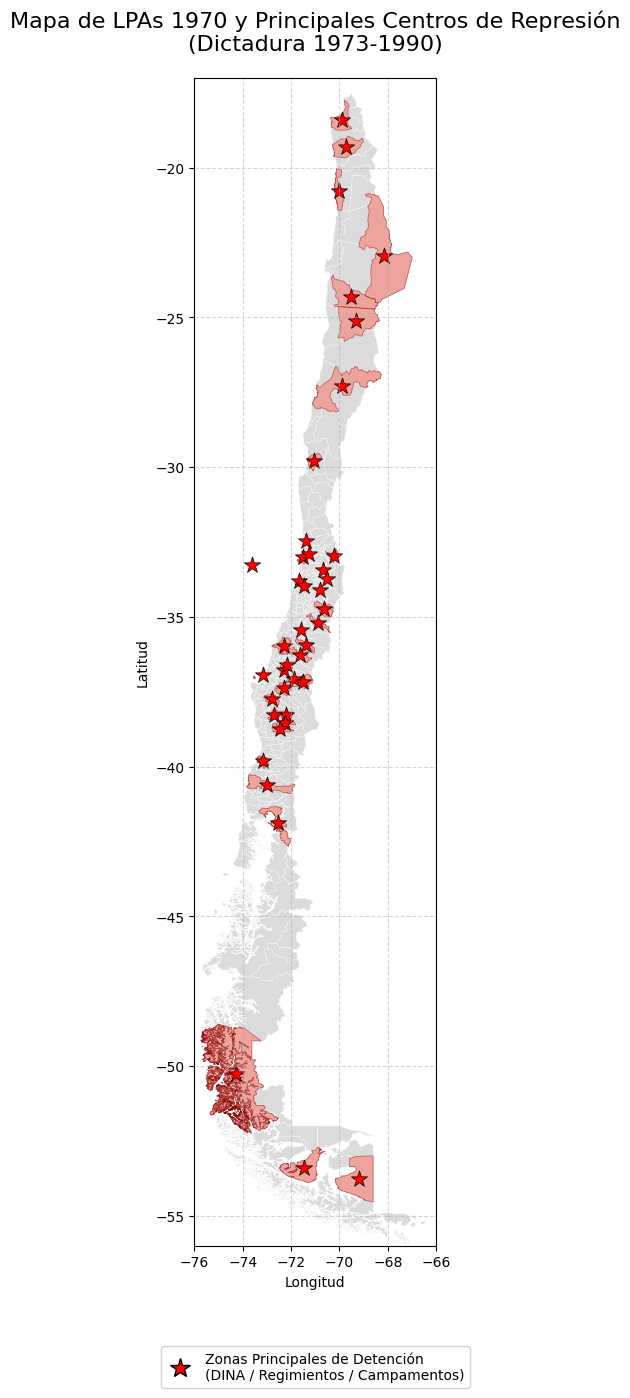

Mapa guardado exitosamente en:
/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/output/figuras/mapa_lpa_detencion.jpg


In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import unicodedata
import re

def normalizar_nombre(txt):
    if pd.isna(txt):
        return ''
    
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z ]', '', txt).strip()
    
    return txt

# ---------------------------------------------------
# 1. Cargar shapefile de comunas 1970
# ---------------------------------------------------

PATH_SHP_1970 = '/Users/Angelo/Dropbox/DPA Historica/Comunas_1970.shp'

gdf_1970 = gpd.read_file(PATH_SHP_1970, encoding='utf-8')

# Normalizar nombres
gdf_1970['comuna'] = gdf_1970['COMUNA'].apply(normalizar_nombre)

# ---------------------------------------------------
# 2. Merge con datos de represión
# ---------------------------------------------------

gdf_mapa = gdf_1970.merge(
    df_final[['comuna', 'es_zona_principal']],
    on='comuna',
    how='left'
)

# ---------------------------------------------------
# 3. Configurar figura
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 16))

# ---------------------------------------------------
# 4. Mapa base
# ---------------------------------------------------

gdf_mapa.plot(
    ax=ax,
    color='lightgray',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.8
)

# ---------------------------------------------------
# 5. Destacar zonas principales
# ---------------------------------------------------

zonas_principales = gdf_mapa[gdf_mapa['es_zona_principal'] == 1]

# Polígonos destacados
zonas_principales.plot(
    ax=ax,
    color='salmon',
    edgecolor='darkred',
    linewidth=0.5,
    alpha=0.6
)

# Centroides con estrella
zonas_principales.centroid.plot(
    ax=ax,
    color='red',
    marker='*',
    markersize=150,
    edgecolor='black',
    linewidth=0.5
)

# ---------------------------------------------------
# 6. Ajustes visuales
# ---------------------------------------------------

plt.title(
    'Mapa de LPAs 1970 y Principales Centros de Represión\n(Dictadura 1973-1990)',
    fontsize=16,
    pad=20
)

plt.xlabel('Longitud')
plt.ylabel('Latitud')

# Limitar al Chile continental
ax.set_xlim([-76, -66])
ax.set_ylim([-56, -17])

# ---------------------------------------------------
# 7. Leyenda personalizada (ABAJO DEL EJE X)
# ---------------------------------------------------

estrella = mlines.Line2D(
    [],
    [],
    color='white',
    marker='*',
    markerfacecolor='red',
    markeredgecolor='black',
    markersize=15,
    label='Zonas Principales de Detención\n(DINA / Regimientos / Campamentos)'
)

ax.legend(
    handles=[estrella],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),  # posición debajo del eje x
    fontsize=10,
    framealpha=0.9
)

# Grilla
plt.grid(True, linestyle='--', alpha=0.5)

# Dejar espacio inferior para la leyenda
plt.subplots_adjust(bottom=0.15)

# ---------------------------------------------------
# 8. Guardar figura
# ---------------------------------------------------

# ✅ CAMBIO AQUÍ: Se cambió la extensión de .png a .jpg
ruta_figura = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/output/figuras/mapa_lpa_detencion.jpg'

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches='tight',
    facecolor='white' # ✅ CAMBIO AQUÍ: Fondo blanco forzado (requerido para JPG)
)

# ---------------------------------------------------
# 9. Mostrar figura
# ---------------------------------------------------

plt.show()

print(f"Mapa guardado exitosamente en:\n{ruta_figura}")
